# Storm tracking analysis

This notebook shows and example of the storm tracking proccedure and the results, and after computes the storms direction and speed for each tracked storm

In [ ]:
# Packages:
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.patches import Ellipse # draw ellipse on figures
import numpy as np
from pyproj import Transformer # convert lat/lon to projected coordinates
import mpu # compute storm centorid movement
from geographiclib.geodesic import Geodesic # compute storm centroid movement
import geopandas as gpd # read shapefiles
import os
import pandas as pd


In [ ]:

# importing the functions to perform the storm tracking
from functions.storm_dataset import storm_tracking_event, continuos_storm, storm_tracking_features


## Loading the storm events in NetCDF file
The file or files should be compose of of a NetCDF file with 3 dimensions: time, longitude and latitude

In [ ]:
# Read the .nc file
file_path = "/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Storm_event.nc


# Read the folder catalog of storm events
path = "/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/RainyDay_Runs/Run_CONUS/Results/Domain_15.0_circle_10000km2/StormCatalog/"
event_list = os.listdir(folder)
event_list = [event for event in event_list if event.endswith('.nc')]


/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_74235/47229368.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  basin_centroid = wsh.geometry.centroid


### Dictionary to store the storm tracking chacateristics for each event

In [ ]:
# Initialize an empty dictionary to store the results
storm_tracking_results = {}
# Iterate over each event in the event_list
event_list.sort()

# Iterate over each event in the event_list
event_list.sort()
for event in event_list:
    # Initialize an empty dictionary for each event
    storm_tracking_results[event] = {}

### Apply a storm tracking method as post-processing
Using the functions storm_tracking.py

In [ ]:

# loading the .nc files
ds = xr.open_dataset(file_path))
# creating dictionary to save the results
event_dict = {}
storm_tracking_event(ds, event_dict)
continuos_storm(event_dict)
storm_tracking_features(event_dict)



The longest storm has a valid duration of 0 hours
The selected duration is shorted than 0.1 of 24 hours, skip this event
Selected storm starts from 2003-07-16T13:00:00.000000000 to 2003-07-17T12:00:00.000000000
Selected storm duration 24 hours


{'storm_pcrp': <xarray.Variable (time: 24, latitude: 150, longitude: 150)> Size: 2MB
 array([[[-9999., -9999., ..., -9999., -9999.],
         [-9999., -9999., ..., -9999., -9999.],
         ...,
         [    0.,     0., ...,     0.,     0.],
         [    0.,     0., ...,     0.,     0.]],
 
        [[-9999., -9999., ..., -9999., -9999.],
         [-9999., -9999., ..., -9999., -9999.],
         ...,
         [    0.,     0., ...,     0.,     0.],
         [    0.,     0., ...,     0.,     0.]],
 
        ...,
 
        [[-9999., -9999., ..., -9999., -9999.],
         [-9999., -9999., ..., -9999., -9999.],
         ...,
         [    0.,     0., ...,     0.,     0.],
         [    0.,     0., ...,     0.,     0.]],
 
        [[-9999., -9999., ..., -9999., -9999.],
         [-9999., -9999., ..., -9999., -9999.],
         ...,
         [    0.,     0., ...,     0.,     0.],
         [    0.,     0., ...,     0.,     0.]]],
       shape=(24, 150, 150), dtype=float32)
 Attributes:
     uni

## Visualizang the results
Next cells show an example to visualize the tracking results for a single event.

In [ ]:
import cartopy.feature as cfeature
from shapely.affinity import translate
from matplotlib.lines import Line2D
from IPython.display import Image, display
import imageio
import cartopy.crs as ccrs  # Ensure Cartopy is imported

## Trajectory event visualization

### The code generates a Gif for a specific storm event showing its centroid trajectories 

The longest storm has a valid duration of 24 hours
The selected duration is longer than 0.1 of 192 hours
Selected storm starts from 2009-10-08T15:00:00.000000000 to 2009-10-09T14:00:00.000000000
Selected storm duration 24 hours


/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_62147/2197316598.py:80: UserWarning: Legend does not support handles for GeoQuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_62147/2197316598.py:80: UserWarning: Legend does not support handles for GeoQuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_62147/2197316598.py:80: UserWarning: Legend does not support handles for GeoQuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
/var/folders/sz/kb5c41rn1w5798nv8cg3h9th0000gn/T/ipykernel_62147/2197316598.py:80: UserWarning: Legend does not support handles for GeoQuadMesh instanc

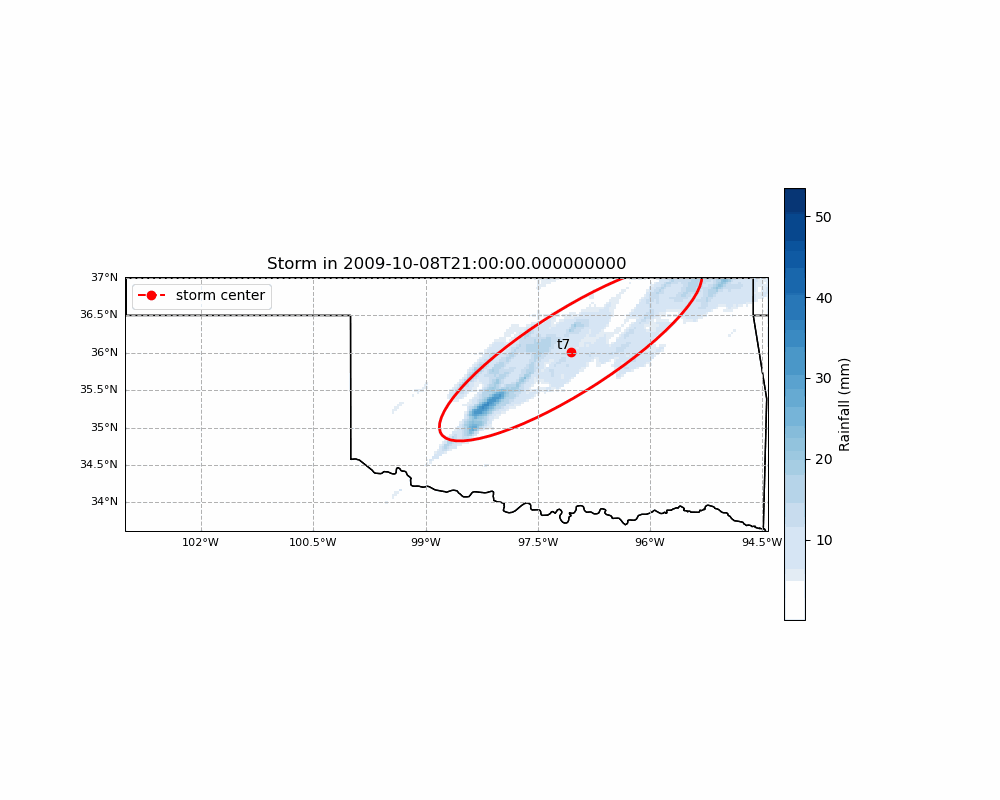

In [ ]:

#folder for storing gif images
output_folder = "frames" 
os.makedirs(output_folder, exist_ok=True)
frame_file = []

t_list = [f't{i}' for i in range(1, event_dict['selected_storm'].shape[0])] # time list for plotting
# Get the maximum and minimum values for the colorbar
cb_max = ds['rain'].values.max()
cb_min = 0.1
start_time_index = 6  # starting time index for the event
end_time_index = 16   # ending time index for the event
## Generation of each time step plot for the event
for time_index in range(start_time_index,end_time_index):
  
    # get current precipitation array
    curr_prcp_array = event_dict['selected_storm'][time_index]
    
    # Create a plot
    
    fig, ax = plt.subplots( figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

    # Plot the projected precipitation data
    rain = ax.pcolormesh(event_dict['lon_array'], event_dict['lat_array'], np.ma.masked_where(curr_prcp_array < 0.1, curr_prcp_array),
                   cmap='Blues', vmax=cb_max, vmin=cb_min, label='Rainfall (mm/h)')
    plt.colorbar(rain, ax=ax, label='Rainfall (mm)', orientation='vertical', shrink=0.7, pad=0.02)
    
    ### Plot the storm centroid
    
    plt.plot(event_dict['storm_lon_cent'][start_time_index:time_index+1], 
             event_dict['storm_lat_cent'][start_time_index:time_index+1], 'ro--', 
               label = 'storm center')
    for lon, lat, label in zip(event_dict['storm_lon_cent'][start_time_index:time_index+1], 
                           event_dict['storm_lat_cent'][start_time_index:time_index+1], 
                           t_list[start_time_index:time_index+1]):
        plt.text(lon, lat, label, fontsize=10, ha='right', va='bottom')
    # plt.scatter(storm_lon_cent, storm_lat_cent)
    # scatter = ax.scatter(x_coords, y_coords, c=precipitation_data, cmap='viridis')
    # plt.colorbar(scatter, ax=ax, label='Precipitation')
    #basin_transposed.plot(ax=ax,  edgecolor='green', facecolor='none', label='Basin')
    
    # Plot the fitted ellipse
    ellipse_artist = Ellipse(
        xy=(event_dict['storm_lon_cent'][time_index], event_dict['storm_lat_cent'][time_index]),
        width=event_dict['storm_record']['matplotlib_width(m)'][time_index]/111000, # the length of horizontal axis
        height=event_dict['storm_record']['matplotlib_height(m)'][time_index]/111000, # the length of vertical axis
        angle=event_dict['storm_record']['ellipse_angle (degree)'][time_index],
        edgecolor='red',
        fill=False,
        linewidth=2,
    )
    ax.add_artist(ellipse_artist)
    # Add U.S. state boundaries
    ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=1)
    # Add grid with labeled coordinates
    gl1 = ax.gridlines(draw_labels=True, linestyle='--')
    gl1.top_labels = False
    gl1.right_labels = False
    font_size = 8  # Set the desired font size
    gl1.xlabel_style = {'size': font_size}  # Set font size for x-axis labels
    gl1.ylabel_style = {'size': font_size}  # Set font size for y-axis labels

    # Set the axis labels
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    title = event_dict['selected_storm_time_steps'].values[time_index]
    ax.set_title(f'Storm in {title}')
    plt.legend()
    # Show the plot
    # Save the frame
    frame_path = os.path.join(output_folder, f"frame_{time_index}.png")
   
    plt.savefig(frame_path)
    plt.close(fig)
    frame_file.append(frame_path)

# Create GIF
gif_path = f"/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/StormTracking_OK/storm_animation_{n_storm}.gif"
imageio.mimsave(gif_path, [imageio.imread(f) for f in frame_file], fps=2)

# Display GIF in IPython notebook
display(Image(filename=gif_path))


## Run storm track for the entire storm catalog

In [10]:
for storm_event in storm_tracking_results.keys():
    ds = xr.open_dataset(os.path.join(folder, storm_event))
    print(storm_event)
    event_dict = {}
    storm_tracking_event(ds, event_dict)
    continuos_storm(event_dict)
    storm_tracking_features(event_dict)
    storm_tracking_results[storm_event] = event_dict

Oklahoma_Watershed_CIMARRON.nc_storm_100_20191007.nc
The longest storm has a valid duration of 23 hours
The selected duration is longer than 0.1 of 192 hours
Selected storm starts from 2019-10-10T12:00:00.000000000 to 2019-10-11T13:00:00.000000000
Selected storm duration 26 hours
Oklahoma_Watershed_CIMARRON.nc_storm_101_20201121.nc
The longest storm has a valid duration of 26 hours
The selected duration is longer than 0.1 of 192 hours
Selected storm starts from 2020-11-28T10:00:00.000000000 to 2020-11-29T11:00:00.000000000
Selected storm duration 26 hours
Oklahoma_Watershed_CIMARRON.nc_storm_102_20211214.nc
The longest storm has a valid duration of 27 hours
The selected duration is longer than 0.1 of 192 hours
Selected storm starts from 2021-12-17T10:00:00.000000000 to 2021-12-18T12:00:00.000000000
Selected storm duration 27 hours
Oklahoma_Watershed_CIMARRON.nc_storm_103_20211226.nc
The longest storm has a valid duration of 17 hours
The selected duration is shorted than 0.1 of 192 hour

/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Paper_Notebooks/Pilot_Study/Pilot_Study/functions/storm_catalog_functions.py:92: RuntimeWarning: invalid value encountered in divide
  x_avg = np.sum((lon_array * curr_prcp_array) / sum_ivt)
/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/Paper_Notebooks/Pilot_Study/Pilot_Study/functions/storm_catalog_functions.py:93: RuntimeWarning: invalid value encountered in divide
  y_avg = np.sum((lat_array * curr_prcp_array) / sum_ivt)


IndexError: index -1 is out of bounds for axis 0 with size 0

## Estimates the storm speed and direction for each storm catalog

In [9]:
# import the functions of storm_direction.py file
from functions.storm_direction import mean_direction, mean_velocity, mean_direction_ln, mean_precipitation_within_ellipse, get_max_accumulated_value, compute_line_length

In [36]:
# list for storing the results
storm_mean_velocity = []
storm_mean_direction_vector = []
storm_mean_direction_lm = []
position=[]

for storm_event in storm_tracking_results.keys():
    storm = storm_tracking_results[storm_event]
    x, y = storm['storm_prj_lon_cent_list'], storm['storm_prj_lat_cent_list']
    
    # Compute the mean velocity and direction
    v = mean_velocity(x, y)
    d = mean_direction(x, y)
    lm = mean_direction_ln(x, y)[0]
    # Append the results to the lists
    storm_mean_velocity.append(v)
    storm_mean_direction_vector.append(d)
    storm_mean_direction_lm.append(lm)
    position.append(storm_event[-20:-12]) # storm ID
    # Saving the results for each storm
    storm_tracking_results[storm_event]['mean_velocity'] = v
    storm_tracking_results[storm_event]['mean_direction'] = d
    storm_tracking_results[storm_event]['mean_direction_ln'] = lm


### Saving the storm properties in dataframe

In [50]:

storm_id = []
for i in position:
    clean_s = re.sub(r'\D', '', i)  # Remove all non-digit characters
    storm_id.append(int(clean_s))

# Dataframe with storm properties
storm_properties = pd.DataFrame({'storm_id': storm_id, 
                                 'mean_velocity': storm_mean_velocity, 
                                 'mean_direction_vector': storm_mean_direction_vector, 
                                 'mean_direction_lm': storm_mean_direction_lm})    

### Plotting windrose

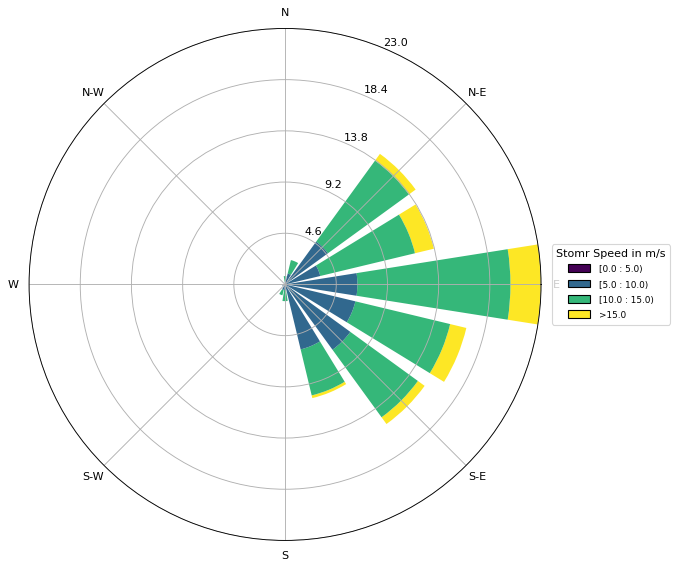

In [17]:
from windrose import WindroseAxes

#Plot Wind Rose
st_dir = np.asarray(storm_mean_direction_vector)+90
st_vel = np.asarray(storm_mean_velocity )
new_labels = ["E", "N-E", "N", "N-W", "W", "S-W", "S", "S-E"]
ax = WindroseAxes.from_ax(theta_labels=new_labels)
ax.bar(st_dir , st_vel, normed=True, bins=np.arange(0, np.max(st_vel), 5))
ax.set_legend(title = 'Stomr Speed in m/s', loc='center right', bbox_to_anchor=(1.25,0.5))